# Product Detection Inference Demo

This notebook demonstrates the trained model's detection capabilities.

## 1. Setup

In [5]:
# Install dependencies (run once)
# !pip install ultralytics opencv-python matplotlib

import sys
from pathlib import Path

# Get project root (works from any location)
NOTEBOOK_DIR = Path().absolute()
if NOTEBOOK_DIR.name == 'notebooks':
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

# Add project to path
sys.path.insert(0, str(PROJECT_ROOT))

# Now import
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np

# Paths
MODEL_PATH = PROJECT_ROOT / 'models/weights/product_detector/weights/best.pt'
TEST_DIR = PROJECT_ROOT / 'data/splits/test/images'

print(f"Project root: {PROJECT_ROOT}")
print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Test dir exists: {TEST_DIR.exists()}")

Project root: /Users/tuvshinjargalanar/itsystem/inventory_project
Model path: /Users/tuvshinjargalanar/itsystem/inventory_project/models/weights/product_detector/weights/best.pt
Model exists: True
Test dir exists: True


In [4]:
# Install required packages (run this cell first!)
!pip install ultralytics opencv-python matplotlib pandas

  Using cached ultralytics-8.4.24-py3-none-any.whl.metadata (39 kB)
  Using cached torch-2.10.0-2-cp312-none-macosx_11_0_arm64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached polars-1.39.3-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached polars_runtime_32-1.39.3-cp310-abi3-macosx_11_0_arm64.whl.metadata (1.5 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
Using cached ultralytics-8.4.24-py3-none-any.whl (1.2 MB)
Using cached polars-1.39.3-py3-none-any.whl (823 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 237.3 kB/s  0:01:59 eta 0:00:010:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 355.0 kB/s  0:04:09 eta 0:00:010:00:07
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 368.9 kB/s  0:00:05359.8 kB/s eta 0:00:01
Using cached ultralytics_

## 2. Load Model

In [6]:
# Load trained model
model = YOLO(MODEL_PATH)

# Print model info
print(f"Model loaded successfully!")
print(f"Classes: {model.names}")

Model loaded successfully!
Classes: {0: 'bonaqua_500ml', 1: 'coca_cola_500ml', 2: 'fanta_500ml', 3: 'sprite_500ml'}


## 3. Single Image Detection

Found 10 test images

Testing on: IMG_6215_jpg.rf.6osGdwNjO31KFuNJwBIx.jpg

image 1/1 /Users/tuvshinjargalanar/itsystem/inventory_project/data/splits/test/images/IMG_6215_jpg.rf.6osGdwNjO31KFuNJwBIx.jpg: 640x480 14 coca_cola_500mls, 70.0ms
Speed: 7.7ms preprocess, 70.0ms inference, 11.1ms postprocess per image at shape (1, 3, 640, 480)


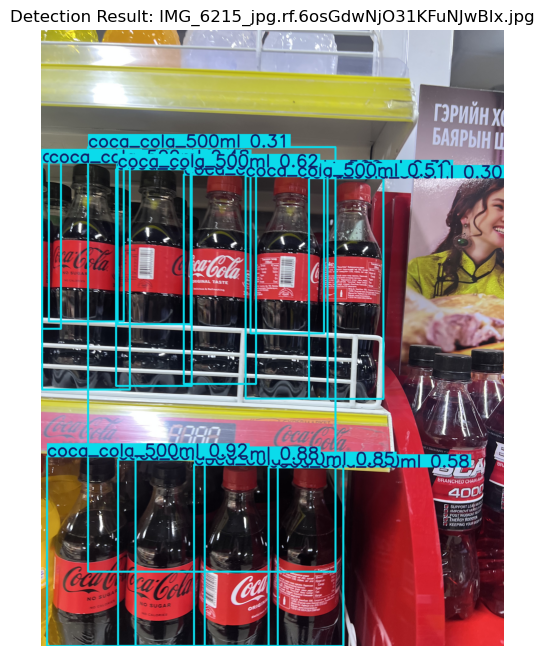


Detections:
  - coca_cola_500ml: 92.37%
  - coca_cola_500ml: 88.50%
  - coca_cola_500ml: 85.12%
  - coca_cola_500ml: 62.36%
  - coca_cola_500ml: 57.91%
  - coca_cola_500ml: 51.33%
  - coca_cola_500ml: 47.71%
  - coca_cola_500ml: 45.12%
  - coca_cola_500ml: 33.54%
  - coca_cola_500ml: 33.05%
  - coca_cola_500ml: 32.50%
  - coca_cola_500ml: 31.11%
  - coca_cola_500ml: 30.13%
  - coca_cola_500ml: 29.92%


In [7]:
# Get test images
test_images = list(TEST_DIR.glob('*.jpg')) + list(TEST_DIR.glob('*.png'))
print(f"Found {len(test_images)} test images")

if test_images:
    # Run detection on first image
    test_img = test_images[0]
    print(f"\nTesting on: {test_img.name}")
    
    results = model.predict(test_img, conf=0.25)
    
    # Display result
    result = results[0]
    annotated = result.plot()
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Detection Result: {test_img.name}')
    plt.show()
    
    # Print detections
    print(f"\nDetections:")
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        cls_name = model.names[cls_id]
        print(f"  - {cls_name}: {conf:.2%}")

## 4. Multiple Image Detection

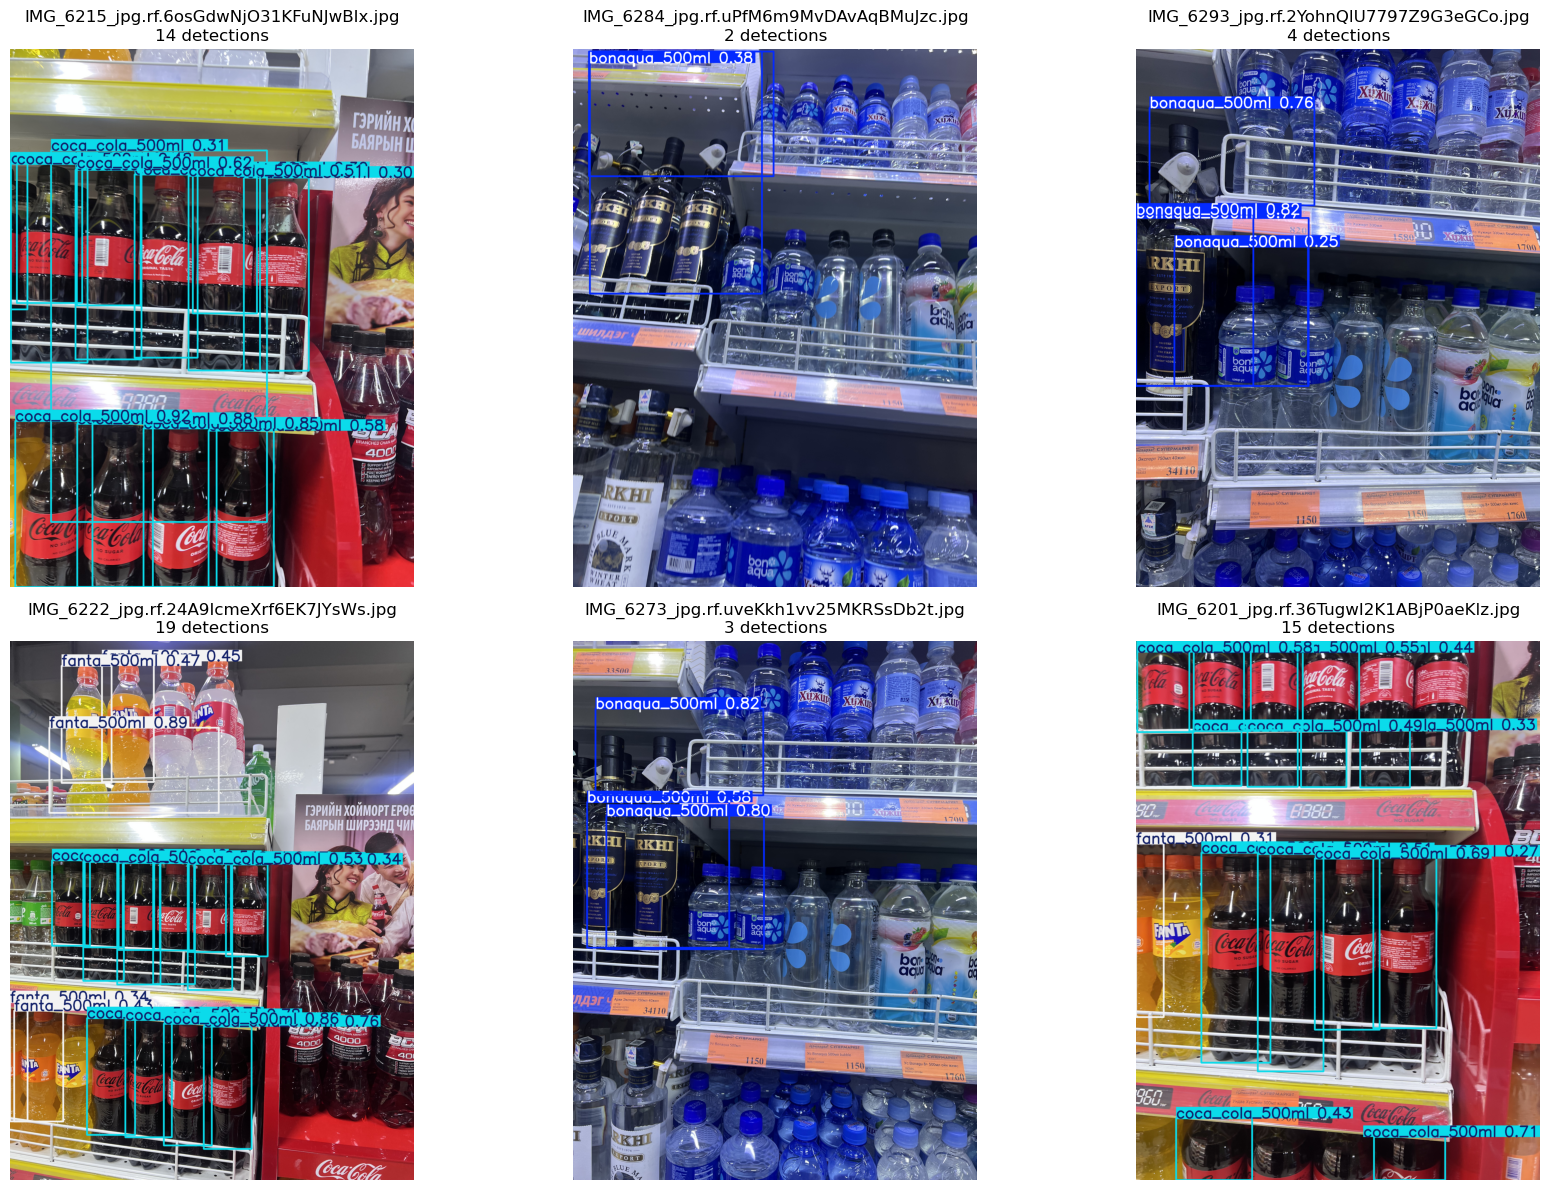

Saved: thesis_inference_samples.png


In [8]:
# Test on multiple images
num_images = min(6, len(test_images))

if num_images > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, img_path in enumerate(test_images[:num_images]):
        results = model.predict(img_path, conf=0.25, verbose=False)
        annotated = results[0].plot()
        
        axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f'{img_path.name}\n{len(results[0].boxes)} detections')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_images, 6):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'models/weights/product_detector/thesis_inference_samples.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved: thesis_inference_samples.png")

## 5. Detection Statistics

In [9]:
# Run inference on all test images and collect stats
all_detections = []
processing_times = []

for img_path in test_images:
    results = model.predict(img_path, conf=0.25, verbose=False)
    result = results[0]
    
    processing_times.append(result.speed['inference'])
    
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        all_detections.append({
            'image': img_path.name,
            'class': model.names[cls_id],
            'confidence': conf
        })

import pandas as pd
det_df = pd.DataFrame(all_detections)

print(f"Total test images: {len(test_images)}")
print(f"Total detections: {len(all_detections)}")
print(f"Average processing time: {np.mean(processing_times):.1f}ms")
print(f"\nDetections per class:")
if len(det_df) > 0:
    print(det_df['class'].value_counts().to_string())

Total test images: 10
Total detections: 87
Average processing time: 54.5ms

Detections per class:
class
coca_cola_500ml    66
fanta_500ml        11
bonaqua_500ml       9
sprite_500ml        1


## 6. Confidence Distribution

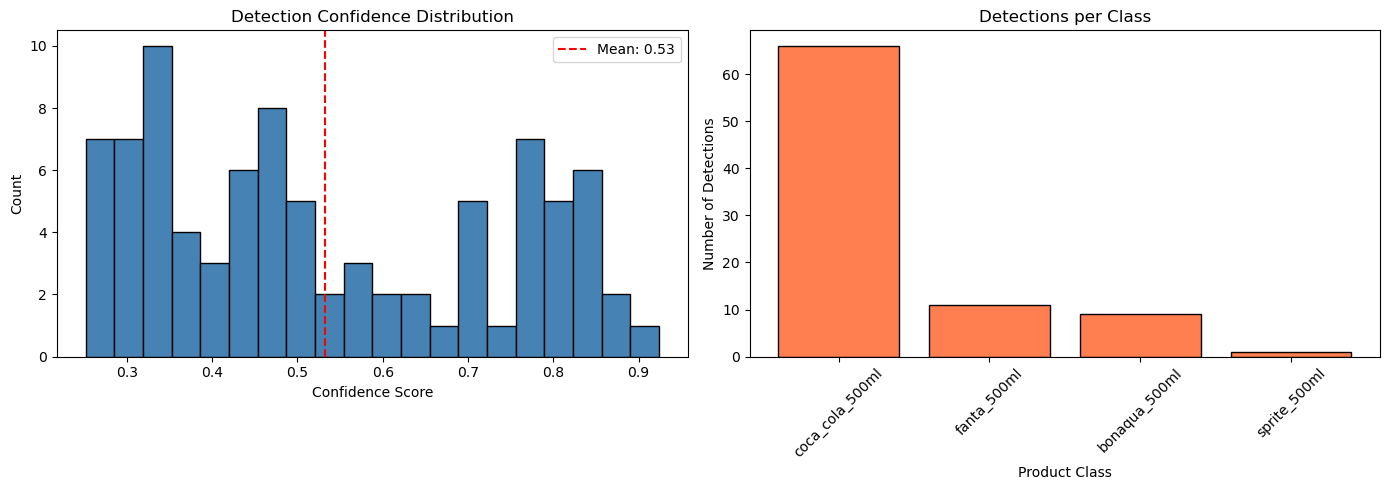

Saved: thesis_detection_stats.png


In [10]:
if len(det_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confidence histogram
    axes[0].hist(det_df['confidence'], bins=20, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Confidence Score')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Detection Confidence Distribution')
    axes[0].axvline(x=det_df['confidence'].mean(), color='red', linestyle='--', 
                    label=f"Mean: {det_df['confidence'].mean():.2f}")
    axes[0].legend()
    
    # Detections per class
    class_counts = det_df['class'].value_counts()
    axes[1].bar(class_counts.index, class_counts.values, color='coral', edgecolor='black')
    axes[1].set_xlabel('Product Class')
    axes[1].set_ylabel('Number of Detections')
    axes[1].set_title('Detections per Class')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'models/weights/product_detector/thesis_detection_stats.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved: thesis_detection_stats.png")

## 7. Custom Image Test

Upload your own image to test the model.

Testing image: /Users/tuvshinjargalanar/itsystem/inventory_project/data/uploads/test.jpg
Image exists: True


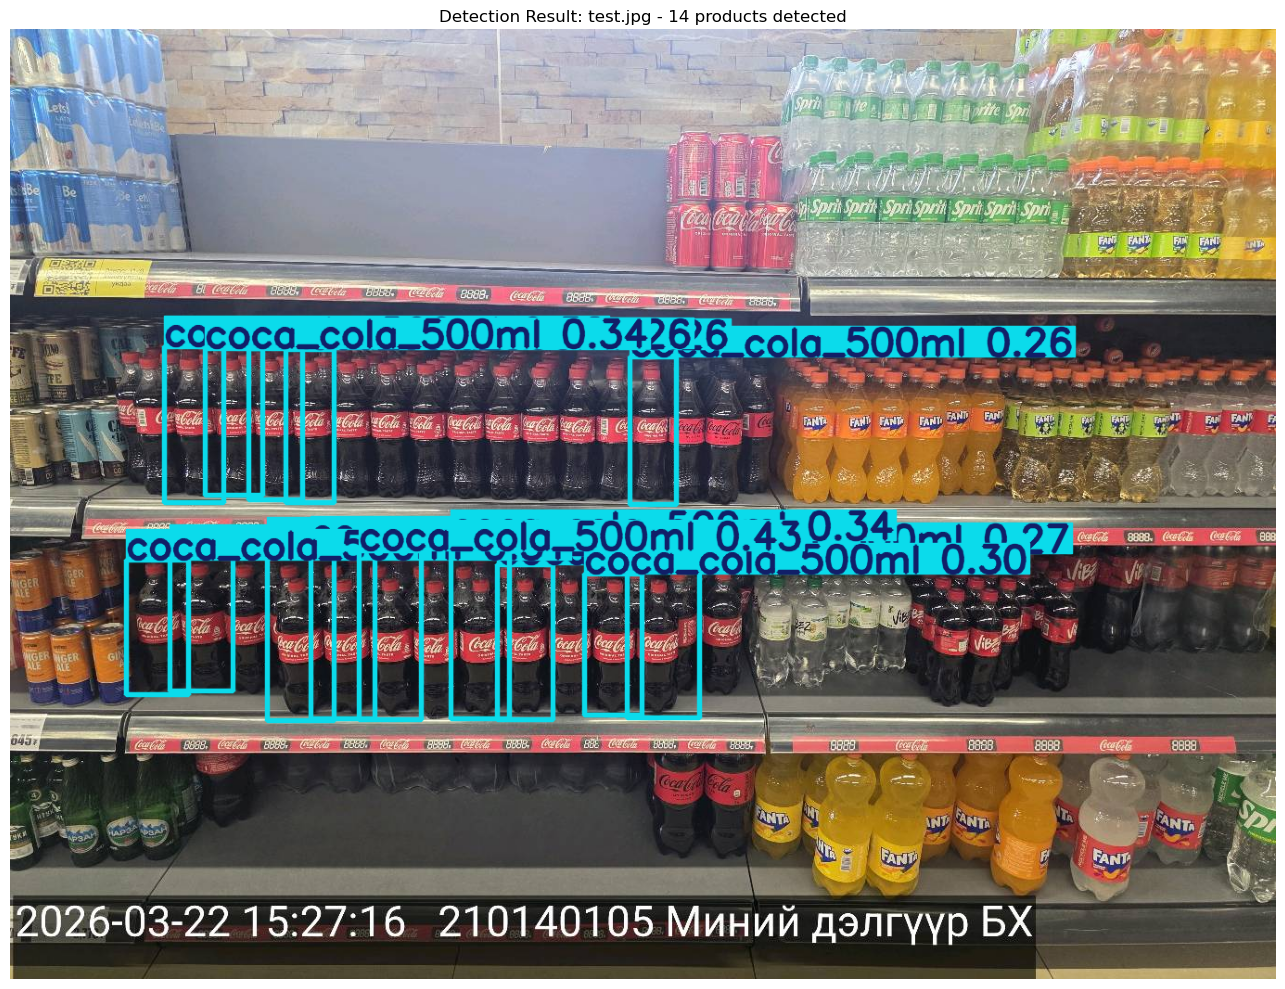


DETECTION RESULTS
Total products detected: 14

Detections:
  1. coca_cola_500ml: 43.2%
  2. coca_cola_500ml: 34.1%
  3. coca_cola_500ml: 33.9%
  4. coca_cola_500ml: 32.4%
  5. coca_cola_500ml: 30.7%
  6. coca_cola_500ml: 29.8%
  7. coca_cola_500ml: 29.8%
  8. coca_cola_500ml: 28.4%
  9. coca_cola_500ml: 27.2%
  10. coca_cola_500ml: 26.9%
  11. coca_cola_500ml: 26.5%
  12. coca_cola_500ml: 26.4%
  13. coca_cola_500ml: 25.9%
  14. coca_cola_500ml: 25.5%

Result saved to: data/uploads/test_result.jpg


In [12]:
# Test with custom image: data/uploads/test.jpg
custom_image = PROJECT_ROOT / 'data/uploads/test.jpg'

print(f"Testing image: {custom_image}")
print(f"Image exists: {custom_image.exists()}")

if custom_image.exists():
    # Run detection
    results = model.predict(str(custom_image), conf=0.25)
    result = results[0]
    
    # Get annotated image
    annotated = result.plot()
    
    # Display
    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Detection Result: test.jpg - {len(result.boxes)} products detected')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'data/uploads/test_result.jpg', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detections
    print(f"\n{'='*50}")
    print(f"DETECTION RESULTS")
    print(f"{'='*50}")
    print(f"Total products detected: {len(result.boxes)}")
    print(f"\nDetections:")
    for i, box in enumerate(result.boxes, 1):
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        cls_name = model.names[cls_id]
        print(f"  {i}. {cls_name}: {conf:.1%}")
    print(f"{'='*50}")
    print(f"\nResult saved to: data/uploads/test_result.jpg")
else:
    print("Image not found!")